# 2. Time validation and limited review capacity
Four outer historical periods. Logistic regression and random forest compete using only earlier inner windows. Constant risk is the baseline; feature-selection and missingness-indicator ablations are fixed comparisons, never inputs to policy selection.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
OUT = ROOT / 'reports/study'
summary = json.loads((OUT / 'summary.json').read_text())
def table(name): return pd.read_csv(OUT / f'{name}.csv')


In [2]:
display(pd.DataFrame(summary['decisions']))
display(table('inner_validation'))
display(table('temporal_metrics'))

,window,selected_model,threshold,fit_end_exclusive,evaluation_end_exclusive
0,1,logistic_selected,0.61,783,940
1,2,logistic_selected,0.80,940,1096
2,3,random_forest,0.25,1096,1253
3,4,logistic_selected,0.82,1253,1567


,outer_window,model,inner_window,train_rows,rows,failures,failure_rate,average_precision,roc_auc,brier_score,status
0,1,logistic_selected,1,391,117,6,0.051282,0.165554,0.605105,0.111044,ok
1,1,logistic_selected,2,508,118,6,0.050847,0.158464,0.778274,0.164686,ok
2,1,logistic_selected,3,626,157,2,0.012739,0.273256,0.864516,0.126322,ok
3,1,random_forest,1,391,117,6,0.051282,0.211746,0.484985,0.066472,ok
4,1,random_forest,2,508,118,6,0.050847,0.147022,0.633929,0.055591,ok
5,1,random_forest,3,626,157,2,0.012739,0.027705,0.545161,0.025246,ok
6,2,logistic_selected,1,470,141,7,0.049645,0.110732,0.704691,0.222019,ok
7,2,logistic_selected,2,611,141,2,0.014184,0.288462,0.910072,0.105922,ok
8,2,logistic_selected,3,752,188,9,0.047872,0.110750,0.533209,0.194664,ok
9,2,random_forest,1,470,141,7,0.049645,0.115376,0.592751,0.058969,ok


,window,model,rows,failures,failure_rate,average_precision,roc_auc,brier_score,status
0,1,selected_policy,157,9,0.057325,0.087197,0.527778,0.148692,ok
1,1,constant_prevalence,157,9,0.057325,0.057325,0.500000,0.054836,ok
2,1,logistic_selected,157,9,0.057325,0.087197,0.527778,0.148692,ok
3,1,random_forest,157,9,0.057325,0.371240,0.703453,0.053726,ok
4,1,rf_without_selection,157,9,0.057325,0.271448,0.650901,0.053207,ok
5,1,rf_missing_indicator,157,9,0.057325,0.166296,0.664414,0.055618,ok
6,2,selected_policy,156,2,0.012821,0.012785,0.250000,0.187879,ok
7,2,constant_prevalence,156,2,0.012821,0.012821,0.500000,0.017284,ok
8,2,logistic_selected,156,2,0.012821,0.012785,0.250000,0.187879,ok
9,2,random_forest,156,2,0.012821,0.028134,0.584416,0.018855,ok


## Recompute rather than copy a headline
Average precision measures ranking. Class-weighted scores are not calibrated failure probabilities. A model can improve ranking while having a much worse Brier score than constant prevalence.

In [3]:
from secom_project.study import score_metrics, capacity_evidence
pred = table('predictions')
last = pred[pred.window == pred.window.max()]
metrics = score_metrics(last.truth, last.risk)
assert np.isclose(metrics['average_precision'], summary['latest_metrics']['average_precision'])
display(pd.Series(metrics).to_frame('recomputed'))
display(capacity_evidence(last.truth, last.risk, [.05,.1,.2,.3]))

,recomputed
rows,314
failures,17
failure_rate,0.05414
average_precision,0.184783
roc_auc,0.646861
brier_score,0.182396
status,ok


,target_capacity,reviewed_runs,actual_capacity,failures,captured,false_alerts,recall,precision,lift,random_expected_captured,random_capture_lower95,random_capture_upper95,random_p_ge_observed_descriptive,boundary_tie_size
0,0.05,16,0.050955,17,3,13,0.176471,0.187500,3.463235,0.866242,0.0,3.0,0.047666,1
1,0.10,32,0.101911,17,5,27,0.294118,0.156250,2.886029,1.732484,0.0,4.0,0.020384,1
2,0.20,63,0.200637,17,6,57,0.352941,0.095238,1.759104,3.410828,1.0,7.0,0.100968,1
3,0.30,95,0.302548,17,8,87,0.470588,0.084211,1.555418,5.143312,2.0,9.0,0.102856,1


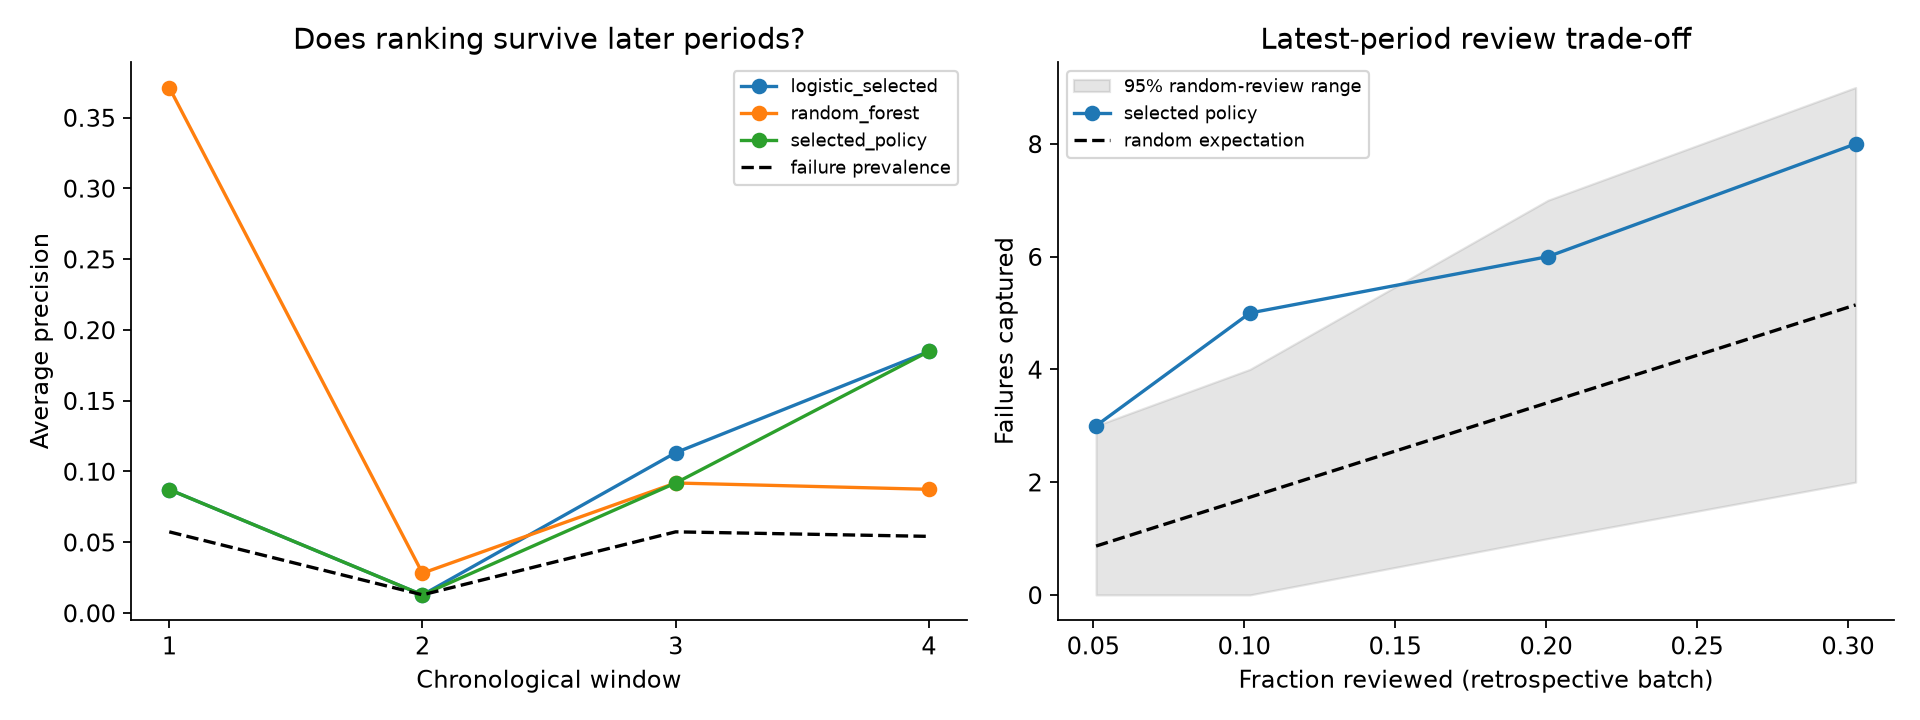

,model,rows,failures,failure_rate,average_precision,roc_auc,brier_score,status
0,logistic_selected,314,21,0.066879,0.175567,0.726150,0.180166,ok
1,random_forest,314,21,0.066879,0.244273,0.738502,0.058957,ok


In [4]:
display(Image(filename=str(OUT/'figures/study_overview.png'), width=1000))
display(table('random_split_diagnostic'))

## What uncertainty means here
Whole-day bootstrap holds the model fixed and resamples just 16 observed days in the latest period. It is not an external-validation guarantee. Random-review intervals describe a separate hypergeometric null, not model-confidence intervals. Report all capacities; do not select the most flattering result.

In [5]:
display(table('conditional_day_bootstrap'))
display(table('illustrative_policy_cost'))

,metric,lower95,upper95,valid_resamples,requested_resamples,observed_days
0,average_precision,0.069610,0.418030,499,500,16
1,roc_auc,0.452062,0.815312,499,500,16
2,capture_at_10pct,0.114052,0.653030,499,500,16
3,capture_at_20pct,0.157938,0.666667,499,500,16


,policy,missed_failures,false_alerts,illustrative_cost
0,frozen_10_to_1_threshold,16,3,163
1,batch_top20,11,57,167
2,review_none,17,0,170
3,review_all,0,297,297


## Cases selected by a fixed rule
The earliest captured failure, missed failure and false alert at 20% batch capacity are shown. This batch policy requires the complete batch; the past-validation percentile is separately frozen and does not update past records when new records arrive.

In [6]:
display(table('case_studies'))

,window,position,run_id,timestamp,truth,risk,threshold,threshold_alert,past_validation_percentile,batch_review_top20,q_residual_top3_only,q_spe,t2,case_type
0,4,1253,1253,2008-10-02 20:54:00,0,0.651984,0.82,False,0.883573,True,sensor_472; sensor_455; sensor_183,3.065126,1.865123,false_alert
1,4,1254,1254,2008-10-02 21:32:00,1,0.699957,0.82,False,0.918660,True,sensor_472; sensor_527; sensor_323,3.360428,2.828806,captured_failure
2,4,1302,1302,2008-10-04 23:18:00,1,0.238252,0.82,False,0.315789,False,sensor_472; sensor_527; sensor_187,2.418424,7.889115,missed_failure
